# 02 — Modèle d'Ising : la température sociale et sa valeur critique

Ce notebook est le **test de validité** du dépôt. L'analogie physique-social n'est
pas falsifiable en tant que telle, mais l'implémentation qui la porte l'est : un
modèle d'Ising 2D correct doit retrouver la température critique exacte calculée par
Onsager en 1944,

$$\frac{T_c}{J} = \frac{2}{\ln(1 + \sqrt{2})} \approx 2{,}269$$

Si le code y parvient, les résultats sociologiques qui en découlent reposent sur une
mécanique statistique juste. Sinon, tout le reste est sans valeur.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.ising import IsingModel, onsager_critical_temperature
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

LATTICE = 24
temperatures = np.round(np.arange(1.6, 3.41, 0.1), 2)
critical = onsager_critical_temperature()
print(f"température critique attendue : {critical:.4f}")

température critique attendue : 2.2692


## Balayage en température

Pour chaque température sociale, on thermalise la population puis on mesure
l'aimantation $|M|$ — le degré de consensus — et la susceptibilité

$$\chi = \frac{N\left(\langle M^2 \rangle - \langle |M| \rangle^2\right)}{T}$$

qui mesure la sensibilité de l'opinion collective à une perturbation. Son maximum
localise la transition.

In [2]:
measurements = [
    IsingModel(
        size=LATTICE, temperature=float(temperature), seed=3, initial_state="aligned"
    ).sample(sweeps=400, burn_in=400)
    for temperature in temperatures
]

consensus = np.array([m["abs_magnetisation"] for m in measurements])
susceptibility = np.array([m["susceptibility"] for m in measurements])
peak = float(temperatures[int(np.argmax(susceptibility))])

print(f"pic de susceptibilité mesuré  : {peak:.2f}  (réseau {LATTICE}x{LATTICE})")
print(f"écart à la valeur d'Onsager   : {peak - critical:+.2f}")

pic de susceptibilité mesuré  : 2.40  (réseau 24x24)
écart à la valeur d'Onsager   : +0.13


### Lecture de l'écart

Le pic mesuré est décalé **vers le haut** par rapport à 2,269. Ce n'est pas une
erreur d'implémentation : sur un réseau fini, la longueur de corrélation ne peut
pas diverger, et le maximum de susceptibilité ne converge vers la valeur exacte que
dans la limite thermodynamique. C'est la raison pour laquelle la suite de tests
tolère ±0,25 sur ce point plutôt qu'une égalité stricte.

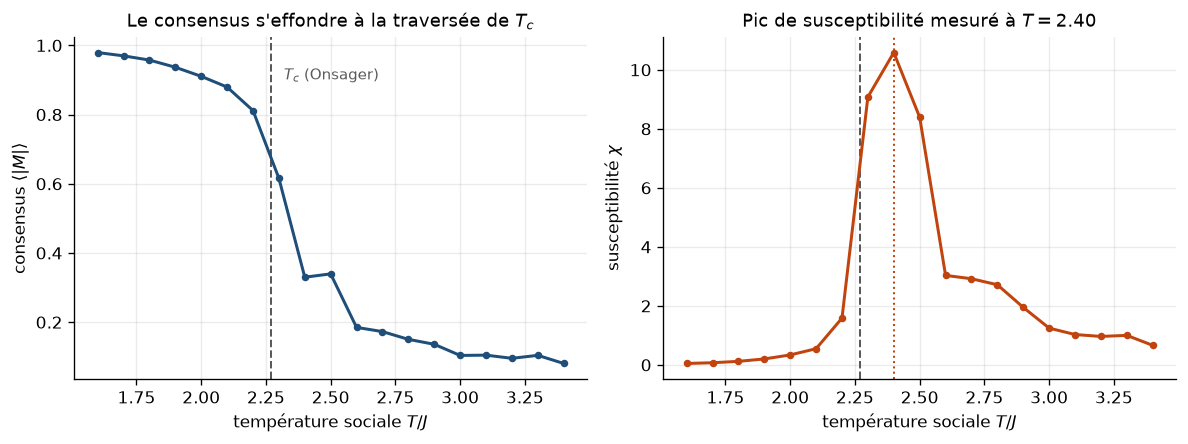

In [3]:
figure, (left, right) = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)

for axes in (left, right):
    axes.axvline(critical, color=PALETTE["neutral"], linestyle="--", linewidth=1.2)
    axes.set_xlabel("température sociale $T / J$")

left.plot(temperatures, consensus, "o-", color=PALETTE["order"], markersize=3.5)
left.set_ylabel(r"consensus $\langle |M| \rangle$")
left.set_title("Le consensus s'effondre à la traversée de $T_c$")
left.text(critical + 0.05, 0.9, r"$T_c$ (Onsager)", color=PALETTE["neutral"], fontsize=9)

right.plot(temperatures, susceptibility, "o-", color=PALETTE["disorder"], markersize=3.5)
right.axvline(peak, color=PALETTE["disorder"], linestyle=":", linewidth=1.2)
right.set_ylabel(r"susceptibilité $\chi$")
right.set_title(f"Pic de susceptibilité mesuré à $T = {peak:.2f}$")

save_figure(figure, "fig02_transition.png")
plt.show()

## Ce que le notebook établit

1. Le modèle reproduit la transition de phase d'Onsager, aux effets de taille finie
   près : la mécanique statistique du dépôt est correcte.
2. La **température sociale** est un paramètre de contrôle réel, pas une métaphore :
   sous $T_c$ la population gèle dans un consensus, au-dessus elle fluctue sans
   jamais s'accorder.
3. Le passage n'est pas graduel mais **critique**. Une société peut donc basculer
   d'un régime à l'autre sur une variation modeste d'agitation — ce qui est
   précisément l'inquiétude que le mémorandum cherche à instrumenter.